In [ ]:
# Environment Setup & Dependency Installation

import sys
import os
import shutil
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import time

# Detect Environment
def in_colab():
    try:
        import google.colab
        return True
    except ImportError:
        return False

IS_COLAB = in_colab()
PYTHON_VERSION = sys.version.split()[0]

print(f"Environment Detected: {'Google Colab' if IS_COLAB else 'Local VS Code / Jupyter'}")
print(f"Kernel Python Version: {PYTHON_VERSION}\n")

# Packages to install
PACKAGES = "transformers datasets evaluate nltk seaborn matplotlib accelerate numpy pandas torch scikit-learn"

if IS_COLAB:
    # --- Colab-Specific Installation ---
    try:
        import pyarrow
        import datasets
        import evaluate
        import sklearn
        NEEDS_INSTALL = False
    except (ImportError, ValueError):
        NEEDS_INSTALL = True

    if NEEDS_INSTALL:
        print("Installing/Updating core dependencies...")
        !pip install -q pyarrow
        !pip install -q {PACKAGES}
        print("✓ Dependencies installed/updated!")
        print("⚠️  Restarting Runtime...")
        print("📝 Re-run the Notebook...")
        time.sleep(2)
        os.kill(os.getpid(), 9)
    else:
        print("✓ Dependencies already installed!")
else:
    # --- Local Jupyter/VS Code Installation ---
    print("Installing/Updating core dependencies")
    try:
        if 'get_ipython' in globals():
            cell_content = f"%%capture\n%pip install -U {PACKAGES}"
            get_ipython().run_cell(cell_content)
            print("✓ Dependencies installed/updated!")
        else:
            print("⚠️  Installation failed: Not running in interactive environment. Run manually.")
    except NameError:
        print("⚠️  Installation failed: Not running in a standard Jupyter kernel. Run manually.")

Environment Detected: Local VS Code / Jupyter
Kernel Python Version: 3.12.10

Installing/Updating core dependencies
✓ Dependencies installed/updated!


In [2]:
# LIBRARY IMPORTS

import warnings
warnings.filterwarnings('ignore', category=UserWarning)

from datasets import load_from_disk
import evaluate

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from sklearn.metrics import confusion_matrix, classification_report
import json
from datetime import datetime
from collections import Counter

# Only needed for Colab-specific functions/display
if IS_COLAB:
    from IPython.display import display, HTML
    # Note: 'files' is imported in the save block if needed.

print("All Libraries Imported Successfully.")

c:\Users\joaqu\AI-News-Classification\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All Libraries Imported Successfully.


In [3]:
print("\n📊 Setting up evaluation environment...\n")

# Define class names (used throughout)
CLASS_NAMES = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}

# Define paths based on environment
if IS_COLAB:
    MODEL_PATH = "/content/models/Distilbert/distilbert-final"
    DATASET_PATH = "/content/data"
    EVAL_OUTPUT_DIR = "/content/models/Distilbert/distilbert-eval"
else:
    # Local paths - notebook is in notebooks/ folder, go up one level
    MODEL_PATH = "../models/Distilbert/distilbert-final"
    DATASET_PATH = "../data"
    EVAL_OUTPUT_DIR = "../models/Distilbert/distilbert-eval"

# Create evaluation output directory
os.makedirs(EVAL_OUTPUT_DIR, exist_ok=True)

# Verify paths exist
if not os.path.exists(DATASET_PATH):
    print(f"Current directory: {os.getcwd()}")
    print(f"Looking for data at: {os.path.abspath(DATASET_PATH)}")
    raise FileNotFoundError(f"❌ Dataset not found at: {DATASET_PATH}")

if not os.path.exists(MODEL_PATH):
    print(f"Looking for model at: {os.path.abspath(MODEL_PATH)}")
    raise FileNotFoundError(f"❌ Model not found at: {MODEL_PATH}")

print(f"✅ Dataset path: {os.path.abspath(DATASET_PATH)}")
print(f"✅ Model path: {os.path.abspath(MODEL_PATH)}")
print(f"✅ Eval output: {os.path.abspath(EVAL_OUTPUT_DIR)}\n")


📊 Setting up evaluation environment...

✅ Dataset path: c:\Users\joaqu\AI-News-Classification\data
✅ Model path: c:\Users\joaqu\AI-News-Classification\models\Distilbert\distilbert-final
✅ Eval output: c:\Users\joaqu\AI-News-Classification\models\Distilbert\distilbert-eval



In [4]:
# CELL 4: Load Data and Model

# Load Test Dataset
print(f"📂 Loading test dataset from: {DATASET_PATH}")
tokenized = load_from_disk(DATASET_PATH)
tokenized_test = tokenized["test"]
print(f"✅ Loaded {len(tokenized_test):,} test samples\n")

# Load Saved Model and Tokenizer
print(f"🤖 Loading model from: {MODEL_PATH}")
loaded_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_PATH,
    local_files_only=True
)
loaded_tokenizer = AutoTokenizer.from_pretrained(
    MODEL_PATH,
    local_files_only=True
)
print(f"✅ Model and tokenizer loaded successfully!\n")

# Setup Evaluation Configuration
print("⚙️  Configuring evaluator...")

# Load evaluation metrics
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    """Compute accuracy and F1 score"""
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_metric.compute(predictions=predictions, references=labels)["accuracy"],
        "f1_macro": f1_metric.compute(predictions=predictions, references=labels, average="macro")["f1"]
    }

# Evaluation configuration
eval_config = TrainingArguments(
    output_dir=EVAL_OUTPUT_DIR,
    per_device_eval_batch_size=16,
    report_to="none",
    logging_dir=os.path.join(EVAL_OUTPUT_DIR, "logs")
)

# Initialize evaluator
evaluator = Trainer(
    model=loaded_model,
    args=eval_config,
    eval_dataset=tokenized_test,
    tokenizer=loaded_tokenizer,
    compute_metrics=compute_metrics
)

print("✅ Evaluation setup complete!\n")

📂 Loading test dataset from: ../data
✅ Loaded 500 test samples

🤖 Loading model from: ../models/Distilbert/distilbert-final
✅ Model and tokenizer loaded successfully!

⚙️  Configuring evaluator...
✅ Evaluation setup complete!



C:\Users\joaqu\AppData\Local\Temp\ipykernel_30176\3413777314.py:46: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  evaluator = Trainer(


🔍 Running evaluation on test set...



EVALUATION RESULTS
Accuracy:   0.8920 (89.20%)
F1 (macro): 0.8927
Loss:       0.3855

🎯 Generating predictions on test set...
✅ Generated 500 predictions

📈 Creating confusion matrix...

💾 Confusion matrix saved to: ../models/Distilbert/distilbert-eval\confusion_matrix.png


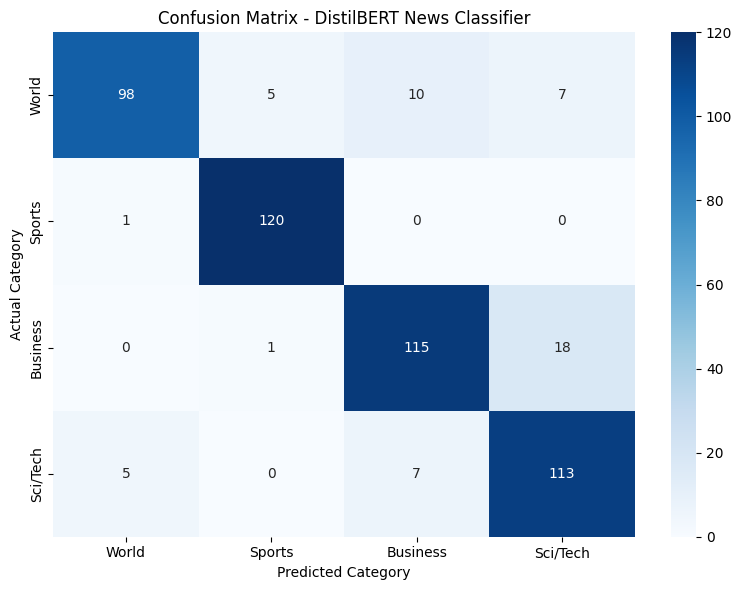


DETAILED CLASSIFICATION REPORT

              precision    recall  f1-score   support

       World       0.94      0.82      0.88       120
      Sports       0.95      0.99      0.97       121
    Business       0.87      0.86      0.86       134
    Sci/Tech       0.82      0.90      0.86       125

    accuracy                           0.89       500
   macro avg       0.90      0.89      0.89       500
weighted avg       0.89      0.89      0.89       500


MISCLASSIFICATION ANALYSIS

Total Misclassified: 54 out of 500 (10.80%)

TOP 5 MISCLASSIFIED EXAMPLES

Example 1:
Text: China's inflation rate slows sharply but problems remain (AFP) AFP - China's inflation rate eased sharply in October as government efforts to cool the economy began to really bite, with food prices, o...
✓ Actual:    World
✗ Predicted: Business

Example 2:
Text: Bookies take bets on new Band Aid Bookies take bets on a new Band Aid single being Christmas No 1, expected to be confirmed by Midge Ure....
✓ Actua

In [5]:
print("🔍 Running evaluation on test set...")
eval_results = evaluator.evaluate()

print(f"\n{'='*60}")
print("EVALUATION RESULTS")
print(f"{'='*60}")
print(f"Accuracy:   {eval_results['eval_accuracy']:.4f} ({eval_results['eval_accuracy']*100:.2f}%)")
print(f"F1 (macro): {eval_results['eval_f1_macro']:.4f}")
print(f"Loss:       {eval_results['eval_loss']:.4f}")
print(f"{'='*60}\n")

# Generate Predictions
print("🎯 Generating predictions on test set...")
prediction_results = evaluator.predict(tokenized_test)
predictions = np.argmax(prediction_results.predictions, axis=1)
actual_labels = prediction_results.label_ids

print(f"✅ Generated {len(predictions):,} predictions\n")

# Confusion Matrix Visualization
print("📈 Creating confusion matrix...\n")
confusion_mat = confusion_matrix(actual_labels, predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES.values(),  # Changed from class_names
            yticklabels=CLASS_NAMES.values())  # Changed from class_names
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.title('Confusion Matrix - DistilBERT News Classifier')
plt.tight_layout()

# Save confusion matrix plot to EVAL_OUTPUT_DIR
confusion_matrix_path = os.path.join(EVAL_OUTPUT_DIR, "confusion_matrix.png")
plt.savefig(confusion_matrix_path, dpi=300, bbox_inches='tight')
print(f"💾 Confusion matrix saved to: {confusion_matrix_path}")
plt.show()
plt.close()

# Detailed Classification Report
print("\n" + "="*60)
print("DETAILED CLASSIFICATION REPORT")
print("="*60 + "\n")

classification_report_text = classification_report(
    actual_labels, 
    predictions, 
    target_names=CLASS_NAMES.values()  # Changed from class_names
)
print(classification_report_text)

classification_report_dict = classification_report(
    actual_labels, 
    predictions, 
    target_names=CLASS_NAMES.values(),  # Changed from class_names
    output_dict=True
)

# Misclassification Analysis
print("\n" + "="*60)
print("MISCLASSIFICATION ANALYSIS")
print("="*60 + "\n")

# Prepare data for analysis
test_data = tokenized_test.remove_columns(['input_ids', 'attention_mask'])
analysis_df = test_data.to_pandas()

# Add predictions and labels
analysis_df['predicted'] = predictions
analysis_df['predicted_label'] = analysis_df['predicted'].map(CLASS_NAMES)  # Changed from class_names
analysis_df['actual_label'] = analysis_df['label'].map(CLASS_NAMES)  # Changed from class_names

# Find misclassifications
misclassified = analysis_df[analysis_df['label'] != analysis_df['predicted']]
total_samples = len(analysis_df)
error_rate = (len(misclassified) / total_samples) * 100

print(f"Total Misclassified: {len(misclassified):,} out of {total_samples:,} ({error_rate:.2f}%)")
print(f"\n{'='*60}")
print("TOP 5 MISCLASSIFIED EXAMPLES")
print(f"{'='*60}\n")

# Collect misclassification examples for saving
misclassification_examples = []

for idx, (_, row) in enumerate(misclassified.head(5).iterrows(), 1):
    text_content = row.get('text', row.get('title', row.get('content', 'Text not available')))
    
    example = {
        "example_number": idx,
        "text": str(text_content)[:300],
        "actual_label": row['actual_label'],
        "predicted_label": row['predicted_label']
    }
    misclassification_examples.append(example)
    
    print(f"Example {idx}:")
    print(f"Text: {str(text_content)[:200]}...")
    print(f"✓ Actual:    {row['actual_label']}")
    print(f"✗ Predicted: {row['predicted_label']}\n")

# Category-Level Error Analysis
print("ERRORS BY CATEGORY\n")

category_errors = misclassified.groupby(['actual_label', 'predicted_label']).size().reset_index(name='count')
category_errors = category_errors.sort_values('count', ascending=False)

print("Most common confusion pairs:")
confusion_pairs = []
for _, row in category_errors.head(10).iterrows():
    pair = {
        "from": row['actual_label'],
        "to": row['predicted_label'],
        "count": int(row['count'])
    }
    confusion_pairs.append(pair)
    print(f"  {row['actual_label']} → {row['predicted_label']}: {row['count']} errors")

# SAVE ALL RESULTS TO FILES
print("\n" + "="*60)
print("💾 SAVING EVALUATION RESULTS")
print("="*60 + "\n")

# 7.1 Save comprehensive JSON report
eval_report = {
    "evaluation_metadata": {
        "timestamp": datetime.now().isoformat(),
        "model_path": MODEL_PATH,
        "dataset_path": DATASET_PATH,
        "dataset_size": total_samples
    },
    "overall_metrics": {
        "accuracy": float(eval_results['eval_accuracy']),
        "accuracy_percentage": float(eval_results['eval_accuracy'] * 100),
        "f1_macro": float(eval_results['eval_f1_macro']),
        "loss": float(eval_results['eval_loss']),
        "error_rate": float(error_rate)
    },
    "per_class_metrics": classification_report_dict,
    "confusion_matrix": confusion_mat.tolist(),
    "misclassification_summary": {
        "total_errors": len(misclassified),
        "error_percentage": float(error_rate),
        "top_confusion_pairs": confusion_pairs,
        "example_misclassifications": misclassification_examples
    }
}

json_report_path = os.path.join(EVAL_OUTPUT_DIR, "evaluation_report.json")
with open(json_report_path, 'w') as f:
    json.dump(eval_report, f, indent=2)
print(f"JSON report saved to: {json_report_path}")

# 7.2 Save text-based classification report
text_report_path = os.path.join(EVAL_OUTPUT_DIR, "classification_report.txt")
with open(text_report_path, 'w', encoding='utf-8') as f:
    f.write("="*60 + "\n")
    f.write("MODEL EVALUATION REPORT\n")
    f.write("="*60 + "\n\n")
    f.write(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Model: {MODEL_PATH}\n")
    f.write(f"Dataset Size: {total_samples:,} samples\n\n")
    f.write("="*60 + "\n")
    f.write("OVERALL METRICS\n")
    f.write("="*60 + "\n")
    f.write(f"Accuracy:   {eval_results['eval_accuracy']:.4f} ({eval_results['eval_accuracy']*100:.2f}%)\n")
    f.write(f"F1 (macro): {eval_results['eval_f1_macro']:.4f}\n")
    f.write(f"Loss:       {eval_results['eval_loss']:.4f}\n\n")
    f.write("="*60 + "\n")
    f.write("PER-CLASS PERFORMANCE\n")
    f.write("="*60 + "\n\n")
    f.write(classification_report_text)
    f.write("\n" + "="*60 + "\n")
    f.write("MISCLASSIFICATION ANALYSIS\n")
    f.write("="*60 + "\n\n")
    f.write(f"Total Errors: {len(misclassified):,} ({error_rate:.2f}%)\n\n")
    f.write("Most Common Confusion Pairs:\n")
    for pair in confusion_pairs[:10]:
        f.write(f"  {pair['from']} → {pair['to']}: {pair['count']} errors\n")

print(f"Text report saved to: {text_report_path}")

# 7.3 Save misclassified examples to CSV
misclassified_csv_path = os.path.join(EVAL_OUTPUT_DIR, "misclassified_samples.csv")
misclassified.to_csv(misclassified_csv_path, index=False)
print(f"Misclassified samples saved to: {misclassified_csv_path}")

# 7.4 Save all predictions to CSV (optional, useful for further analysis)
full_predictions_path = os.path.join(EVAL_OUTPUT_DIR, "all_predictions.csv")
analysis_df.to_csv(full_predictions_path, index=False)
print(f"All predictions saved to: {full_predictions_path}")

print(f"\nAll results saved to: {os.path.abspath(EVAL_OUTPUT_DIR)}/")
print("\nEvaluation Complete!")